### Libraries

In [1]:
import numpy as np
import pandas as pd
import random

from scipy.optimize import root
from scipy.stats import multivariate_normal

from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

from gmm_explainer import CFE_explainer

import matplotlib.pyplot as plt

from time import process_time

### Globals

In [2]:
random_seed = 42

### Create dataset

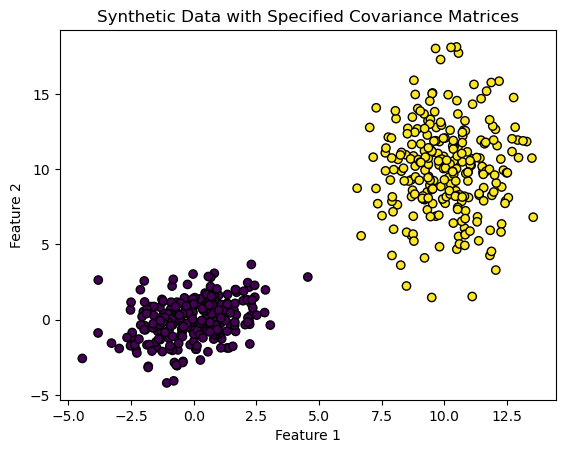

In [3]:
# Parameters
centers = np.array([[0.0, 0.0], [10.0, 10.0]])

covariances = np.array([[[2.0, 0.6], 
                         [0.6, 2.0]], 
                        [[2, 0.4], 
                         [0.4, 10.0]]])
n_samples = 500
random_seed = 42

# Ensure reproducibility
np.random.seed(random_seed)

# Generate synthetic 2D data
X = []
y = []
samples_per_cluster = n_samples // len(centers)

for i, (mean, cov) in enumerate(zip(centers, covariances)):
    cluster_data = np.random.multivariate_normal(mean, cov, samples_per_cluster)
    X.append(cluster_data)
    y.append([i] * samples_per_cluster)

# Combine data from clusters
X = np.vstack(X)
y = np.hstack(y)

# Plot the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Data with Specified Covariance Matrices")
plt.show()

### Fit the GMM

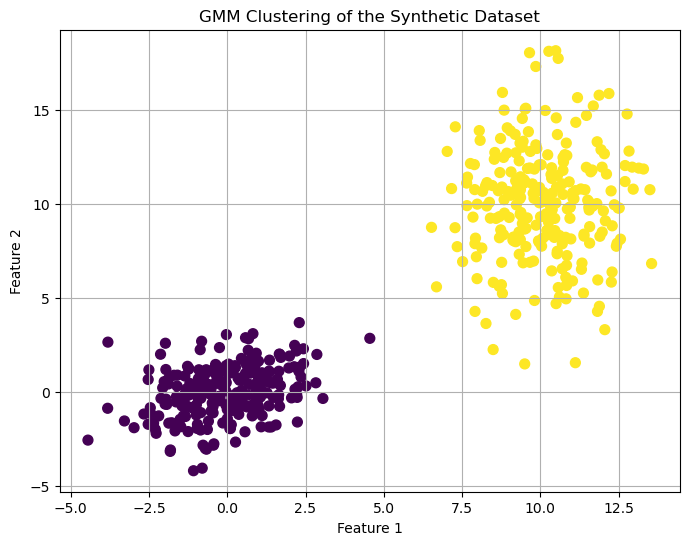

In [4]:
n_clusters = 2
gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=random_seed)
gmm.fit(X)

# Predict the labels (clusters) for the data points
y_gmm = gmm.predict(X)

# Plot the original dataset and GMM clusters
plt.figure(figsize=(8, 6))

# Scatter plot of the data colored by the GMM predicted labels
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis', s=50, marker='o', label='GMM clusters')
plt.title('GMM Clustering of the Synthetic Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

### Save dataset

In [5]:
# Create a pandas DataFrame with the X and Y coordinates and the predicted GMM cluster labels
data = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    'c_label': y_gmm
})

# Save the DataFrame to a CSV file
data.to_csv('./data.csv', index=False)

### Create factuals uniformly at random

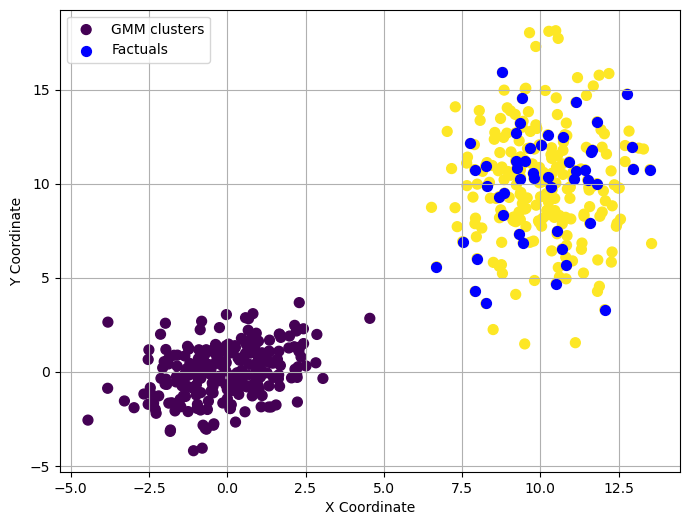

In [6]:
np.random.seed(random_seed)

# Number of samples and bounds
n_factuals = 50


sampled_indexes = np.random.choice(np.where(y_gmm == 1)[0], size=n_factuals, replace=False)

factuals = X[sampled_indexes]

# Plot the uniformly distributed data
plt.figure(figsize=(8, 6))
# plt.title(f'Uniformly Distributed 2D Points (n={n_factuals})')
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, cmap='viridis', s=50, marker='o', label='GMM clusters')
plt.scatter(factuals[:, 0], factuals[:, 1], c='blue', s=50, marker='o', label='Factuals')

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

plt.grid(True)
plt.legend()
plt.show()

### Save factuals

In [7]:
df_factuals = pd.DataFrame({
    'x': factuals[:, 0],
    'y': factuals[:, 1],
    'c_label': gmm.predict(factuals),
})

In [8]:
# Save the DataFrame to a CSV file
df_factuals.to_csv('./factuals.csv', index=False)

### Hyperparameters

In [9]:
# Allowed features to change
mask = np.array([1, 1])  

# Epsilon penalty
epsilon = 1

# Priors
prior_1 = 1/2
prior_2 = 1/2

In [10]:
cfes_list = list()

m1, m2 = gmm.means_
S1, S2 = gmm.covariances_

In [11]:
explainer = CFE_explainer(m1, m2, S1, S2, prior_1, prior_2)

In [12]:
for i, x_init in enumerate(factuals):
    z_optimal = explainer.compute_counterfactual(x_init, mask, epsilon)
    cfes_list.append(z_optimal)

### Results

In [15]:
# Print the optimal z
print("Optimal z:", z_optimal)

# Calculate the probability density of z_optimal from both normal distributions
pdf1 = multivariate_normal.pdf(z_optimal, mean=m1, cov=S1)
pdf2 = multivariate_normal.pdf(z_optimal, mean=m2, cov=S2)

print("Probability density of z from the first normal distribution: ", pdf1)
print("Probability density of z from the second normal distribution: ", pdf2)

Optimal z: [4.35843692 5.81830935]
Probability density of z from the first normal distribution:  2.387180652733622e-06
Probability density of z from the second normal distribution:  4.774361305467228e-06
